# Data Exploration

In [1]:
import os
import time
import pyproj

import pandas as pd
import polars as pl
import numpy as np
import geopandas as gpd
from shapely.validation import make_valid

import matplotlib.pyplot as plt
import seaborn as sns

from esda.moran import Moran
from spreg import OLS, ML_Error, ML_Lag, GM_Error, GM_Lag
from splot.esda import moran_scatterplot, plot_moran
import contextily as ctx
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter
import textwrap
from libpysal.weights import lag_spatial
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

import libpysal as ps 
from libpysal.weights import Queen
from esda.moran import Moran
import statsmodels.api as sm

import duckdb

In [2]:
os.environ['OGR_ORGANIZE_POLYGONS'] = 'SKIP' 
# Creates .db file in the project folder
conn = duckdb.connect(r"/Users/sammi/Dissertation2026/project.db")
conn.execute("LOAD spatial;")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [3]:
key_cols = ['UPRN', 'dateoftransfer', 'transactionid', 'price', 'flood_start', 'flood_end', 'real_price_dec_2024', 'transfer_date_shifted', 
            'real_price_2024_shifted', 'flood_bracket', 'real_price_dec_2024_log', 'real_price_2024_shifted_log', 'price_diff', 'log_price_diff', 
            'propertytype',   'X_COORDINATE', 'Y_COORDINATE', 'in_flood_zone', 'in_border_zone', 'border_zone_bracket', 'greenspace_area', 'buffer_area', 
            'greenspace_proportion', 'Z', 'pcds', 'lsoa21cd', 'LSOA11CD', 'LSOA code (2011)', 'IMD_Income_Dec_2019', 'TOTAL_FLOOR_AREA', 'geometry', 
            'year_t', 'year_v', 'n_floods_history', 'flood_start_', 'flood_end_', 'flood_duration', 'flood_duration_days']

x_cols = ['real_price_dec_2024', 'log_price_diff', 'year_t', 'year_v',
          'TOTAL_FLOOR_AREA','greenspace_proportion', 'Z',
          'IMD_Income_Dec_2019', 'n_floods_history', 'flood_duration_days']

In [4]:
model_df = conn.execute("""SELECT *
                        EXCLUDE geometry, ST_AsText(geometry) as geometry
                        FROM model_data.modelling_data""").fetchdf()
model_df = pl.from_pandas(model_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
normal_df = model_df.filter(
    (pl.col('log_price_diff') > pl.col('log_price_diff').quantile(0.01)) &
    (pl.col('log_price_diff') < pl.col('log_price_diff').quantile(0.99))
)

In [6]:
bracket_uprns = normal_df.filter(pl.col('flood_bracket') ==1)
print(len(normal_df), bracket_uprns['UPRN'].n_unique(), len(bracket_uprns) )

2329134 9869 10117


In [7]:

"""fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Distribution of Price per Square Meter — London Residential Transactions (1995–2024)",
             fontsize=14, fontweight="bold", y=1.01
             )

# Histogram of price per sqm:
ax0 = axes[0]

price = model_df['log_price_diff']
         
sns.histplot(price, kde=True, ax=ax0,
             color="#BF90E6", edgecolor="black", linewidth=0.4,
             bins=100, alpha=0.85,
             line_kws={"color": "#000000", "linewidth": 2}
             )

ax0.set_title("Log price first difference - Histogram", fontsize=12, fontweight="bold", pad=10)
ax0.set_xlabel("Log price first difference (£)", fontsize=10)
ax0.set_ylabel("Count", fontsize=10)

# Jitter Plot of price per sqm:
ax1 = axes[1]
normal_prices = normal_df['log_price_diff']

bracket_uprns = normal_df.filter(pl.col('flood_bracket') ==1)
print(len(normal_df), bracket_uprns['UPRN'].n_unique(), len(bracket_uprns) )

# Take a sample of the data for better visualization as dataset is large
sns.histplot(normal_prices, kde=True, ax=ax1,
             color="#DDCF0B", edgecolor="black", linewidth=0.4,
             bins=100, alpha=0.85,
             line_kws={"color": "#000000", "linewidth": 2}
             )

ax1.set_title("Log price first difference - Histogram", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("Log price first difference (£)", fontsize=10)
ax1.set_ylabel("Count", fontsize=10)

# Layout and styling:
for ax in axes:
    ax.tick_params(labelsize=9)
    ax.grid(False)

fig.tight_layout()
plt.show()"""

'fig, axes = plt.subplots(1, 2, figsize=(18, 7))\nfig.suptitle("Distribution of Price per Square Meter — London Residential Transactions (1995–2024)",\n             fontsize=14, fontweight="bold", y=1.01\n             )\n\n# Histogram of price per sqm:\nax0 = axes[0]\n\nprice = model_df[\'log_price_diff\']\n\nsns.histplot(price, kde=True, ax=ax0,\n             color="#BF90E6", edgecolor="black", linewidth=0.4,\n             bins=100, alpha=0.85,\n             line_kws={"color": "#000000", "linewidth": 2}\n             )\n\nax0.set_title("Log price first difference - Histogram", fontsize=12, fontweight="bold", pad=10)\nax0.set_xlabel("Log price first difference (£)", fontsize=10)\nax0.set_ylabel("Count", fontsize=10)\n\n# Jitter Plot of price per sqm:\nax1 = axes[1]\nnormal_prices = normal_df[\'log_price_diff\']\n\nbracket_uprns = normal_df.filter(pl.col(\'flood_bracket\') ==1)\nprint(len(normal_df), bracket_uprns[\'UPRN\'].n_unique(), len(bracket_uprns) )\n\n# Take a sample of the data

In [8]:
df = bracket_uprns.to_pandas()
gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['geometry']),  crs='EPSG:27700')
gdf.head()

,UPRN,dateoftransfer,transactionid,price,flood_start,flood_end,real_price_dec_2024,transfer_date_shifted,real_price_2024_shifted,flood_bracket,...,IMD_Income_Dec_2019,TOTAL_FLOOR_AREA,year_t,year_v,n_floods_history,flood_start_,flood_end_,flood_duration,flood_duration_days,geometry
0,511331,2003-11-07,{43534F3F-3CF8-46D7-9763-B15A4A90815A},200000,2000-10-30T00:00:00.000,2000-10-31T00:00:00.000,461072.261072,1996-07-05,387000.000000,1,...,6.0,99.0,1996.0,2003.0,1,2000-10-30,2000-10-31,1 days,1.0,POINT (363830 170449)
1,511332,2016-01-15,{2D1E4B25-EF8E-FCD1-E050-A8C0630544EC},215000,2014-01-05T00:00:00.000,2014-01-05T00:00:00.000,312239.353891,2002-10-11,500856.041131,1,...,6.0,59.0,2002.0,2016.0,1,2014-01-05,2014-01-05,0 days,0.0,POINT (363824 170453)
2,538715,2015-05-22,{31FB4C16-CFCE-57B9-E050-A8C063053436},310700,2000-10-30T00:00:00.000,2000-10-31T00:00:00.000,480128.593750,2000-09-01,577518.248175,1,...,10.0,83.0,2000.0,2015.0,1,2000-10-30,2000-10-31,1 days,1.0,POINT (365726.89 179443.8)
3,538775,2022-09-28,{EED73E75-8E59-6AF3-E053-6C04A8C08ABA},450000,2000-10-30T00:00:00.000,2000-10-31T00:00:00.000,447736.418511,1999-12-10,505021.276596,1,...,10.0,79.0,1999.0,2022.0,1,2000-10-30,2000-10-31,1 days,1.0,POINT (365707 179434)
4,11006615,2013-08-02,{F7ECF7C6-F922-4D63-A749-9FFE56C58950},72000,2007-06-26T00:00:00.000,2007-06-26T00:00:00.000,111431.164902,2006-05-05,109080.691643,1,...,2.0,77.0,2006.0,2013.0,1,2007-06-26,2007-06-26,0 days,0.0,POINT (524449 409573)


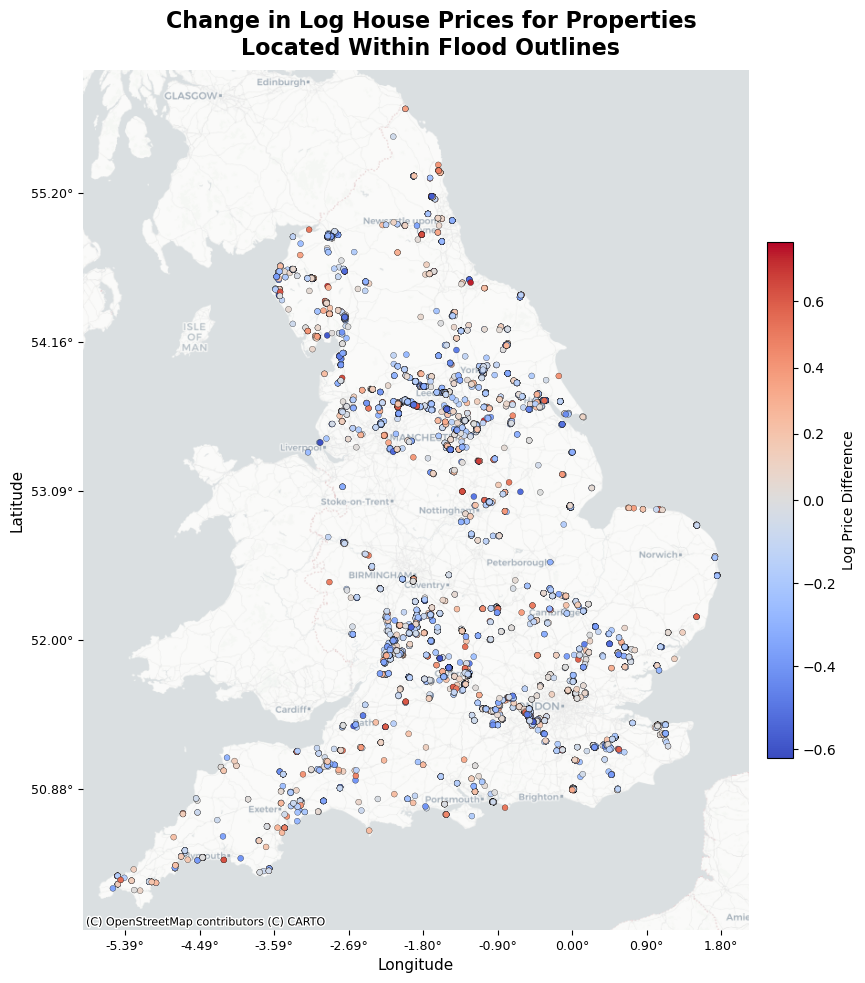

In [9]:
gdf_web = gdf.to_crs('EPSG:3857')

# Centre the diverging colormap on zero so red/blue reflect sign, not just magnitude
vmin, vmax = gdf_web['log_price_diff'].min(), gdf_web['log_price_diff'].max()
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle(
    'Change in Log House Prices for Properties\nLocated Within Flood Outlines',
    fontsize=16, fontweight='bold', y=0.98
)


gdf_web.plot(
    ax=ax, column='log_price_diff', cmap='coolwarm', norm=norm,
    markersize=18, alpha=1.0, edgecolor='black', linewidth=0.2,
    legend=True,
    legend_kwds={
        'label': 'Log Price Difference',
        'shrink': 0.6,
        'pad': 0.02,
    }
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto', alpha = 0.85)

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)

transformer = pyproj.Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)

def lon_formatter(x, pos):
    lon, _ = transformer.transform(x, 0)
    return f'{lon:.2f}°'

def lat_formatter(y, pos):
    _, lat = transformer.transform(0, y)
    return f'{lat:.2f}°'

ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
ax.tick_params(labelsize=9)

# Clean frame
for spine in ax.spines.values():
    spine.set_visible(False)


fig.subplots_adjust(left=0.1, right=0.9, top=0.92, bottom=0.06)
plt.savefig('log_price_diff_map.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

## VIF:

Create dummy columns for property types:

In [69]:
normal_df = normal_df.with_columns(
    detached_dummy = pl.when((pl.col("propertytype") == 'D'))
        .then(1)
        .otherwise(0)
        .cast(pl.Float64),
    terrace_dummy = pl.when((pl.col("propertytype") == 'T'))
        .then(1)
        .otherwise(0)
        .cast(pl.Float64),
    semi_detach_dummy = pl.when((pl.col("propertytype") == 'S'))
        .then(1)
        .otherwise(0)
        .cast(pl.Float64),
    flat_dummy = pl.when((pl.col("propertytype") == 'F'))
        .then(1)
        .otherwise(0)
        .cast(pl.Float64)
)

In [70]:
normal_df = normal_df.with_columns(
    pl.col("flood_duration_days").fill_null(0)
)

In [71]:
x_cols = [ 'year_t', 'year_v','TOTAL_FLOOR_AREA','greenspace_proportion', 'Z',
          'IMD_Income_Dec_2019', 'n_floods_history', 'flood_duration_days', 
          'detached_dummy', 'terrace_dummy' , 'semi_detach_dummy']

X_vif = normal_df[x_cols]
X_vif = X_vif.to_pandas()

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                 Variable            VIF
1                  year_v  128083.070264
0                  year_t  127858.642242
5     IMD_Income_Dec_2019       6.871082
2        TOTAL_FLOOR_AREA       6.424571
9           terrace_dummy       3.217419
10      semi_detach_dummy       2.741806
8          detached_dummy       2.727040
4                       Z       2.502376
3   greenspace_proportion       1.221982
6        n_floods_history       1.041045
7     flood_duration_days       1.027692


In [72]:
X_with_const = sm.add_constant(X_vif)
vif_data = pd.DataFrame()
vif_data['Variable'] = X_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

print(vif_data[vif_data['Variable'] != 'const'])

                 Variable       VIF
1                  year_t  1.929344
2                  year_v  1.949166
3        TOTAL_FLOOR_AREA  1.293317
4   greenspace_proportion  1.002654
5                       Z  1.013354
6     IMD_Income_Dec_2019  1.087881
7        n_floods_history  1.029570
8     flood_duration_days  1.027557
9          detached_dummy  2.201015
10          terrace_dummy  2.064987
11      semi_detach_dummy  1.994614


## Spatial Weight Matrix:

In [67]:
from libpysal.weights import DistanceBand, KNN

In [90]:
print(normal_df['UPRN'].n_unique())
print(normal_df['geometry'].n_unique())

1360138
1256485


In [ ]:
df = normal_df.to_pandas()
gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['geometry']),  crs='EPSG:27700')

In [102]:
gdf_uprns = gdf['UPRN'].unique()
unique_geoms = gpd.GeoSeries(gdf['geometry'].unique(), crs=gdf.crs)

In [105]:
# Extract projected coordinates for distance calculations
gdf_proj = unique_geoms.to_crs('EPSG:27700')
coords = np.column_stack((gdf_proj.x, gdf_proj.y))

# ---- KNN Weight Matrix ----
w_knn = KNN.from_array(coords, k=8)
w_knn.transform = 'R'  # Row-standardise

print("=== KNN Spatial Weights (k=5) ===")
print(f"Number of observations: {w_knn.n}")
print(f"Mean number of neighbours: {w_knn.mean_neighbors:.1f}")
print(f"Min neighbours: {w_knn.min_neighbors}")
print(f"Max neighbours: {w_knn.max_neighbors}")

c:\Users\sammi\anaconda3\envs\Regressions\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3320 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


=== KNN Spatial Weights (k=5) ===
Number of observations: 1256485
Mean number of neighbours: 8.0
Min neighbours: 8
Max neighbours: 8


In [111]:
y_col = ['log_price_diff']

ys = df[y_col].values

xs = df[x_cols].values

In [ ]:
# Run OLS:
ols = OLS(ys, xs,
          w=w_knn,
          name_y=y_col,
          name_x=x_cols,
          name_ds='UPPT',
          spat_diag=True 
          )

print(ols.summary)

# Moran's I test for spatial autocorrelation in OLS residuals
residuals = ols.u.flatten()
moran = Moran(residuals, w_knn)

print("====================== Global Moran's I Test on OLS Residuals ======================")
print(f"Moran's I:     {moran.I:.4f}")
print(f"Expected I:    {moran.EI:.4f}")
print(f"Z-score:       {moran.z_sim:.4f}")
print(f"P-value:       {moran.p_sim:.4f}")
print()

Exception: y must have n rows, and w must be an nxn PySAL W object